# ML Ops - Final Project

## 1.0 Setup

In [1]:
###### Import Libraries ######

# Environment/setup checks
import subprocess
from pathlib import Path
import sys

# Core data handling
import pandas as pd
import numpy as np
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train/test split and modeling
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report

# Feature store
from feast import FeatureStore

# Display settings
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings("ignore")

print("Python:", sys.version)
print("pandas:", pd.__version__)

Python: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:23:37) [Clang 14.0.6 ]
pandas: 2.3.3


In [2]:
# Initialize Git, DVC and Feast (only initializes if not already present)
if not Path("../.git").exists():
    print("Initializing Git repository...")
    subprocess.run(["git", "init", ".."], check=True)
else:
    print("Git repo already initialized — skipping.")

if not Path("../.dvc").exists():
    print("Initializing DVC...")
    subprocess.run(["dvc", "init"], cwd="..", check=True)
else:
    print("DVC already initialized — skipping.")

if not Path("../feast_repo/feature_repo/feature_store.yaml").exists():
    print("Initializing Feast feature repo...")
    subprocess.run(["feast", "init", "feast_repo"], cwd="..", check=True)
else:
    print("Feast feature repo already initialized — skipping.")

Git repo already initialized — skipping.
DVC already initialized — skipping.
Feast feature repo already initialized — skipping.


In [3]:
# Import raw data
df_raw = pd.read_csv("../data/raw/diabetic_data.csv")
print(df_raw.shape)
df_raw.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 2.0 Preprocessing

### 2.1 Inspect Raw Data

In [4]:
# Basic structure
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [5]:
# Replace '?' placeholder with actual NaN
df_raw = df_raw.replace('?', np.nan)

# Missing values per column
missing = df_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(1)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
weight,98569,96.9
max_glu_serum,96420,94.7
A1Cresult,84748,83.3
medical_specialty,49949,49.1
payer_code,40256,39.6
race,2273,2.2
diag_3,1423,1.4
diag_2,358,0.4
diag_1,21,0.0
encounter_id,0,0.0


### 2.2 Raw Distributions

In [6]:
# Generate basic statistics
df_raw.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


Numeric columns (13): ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


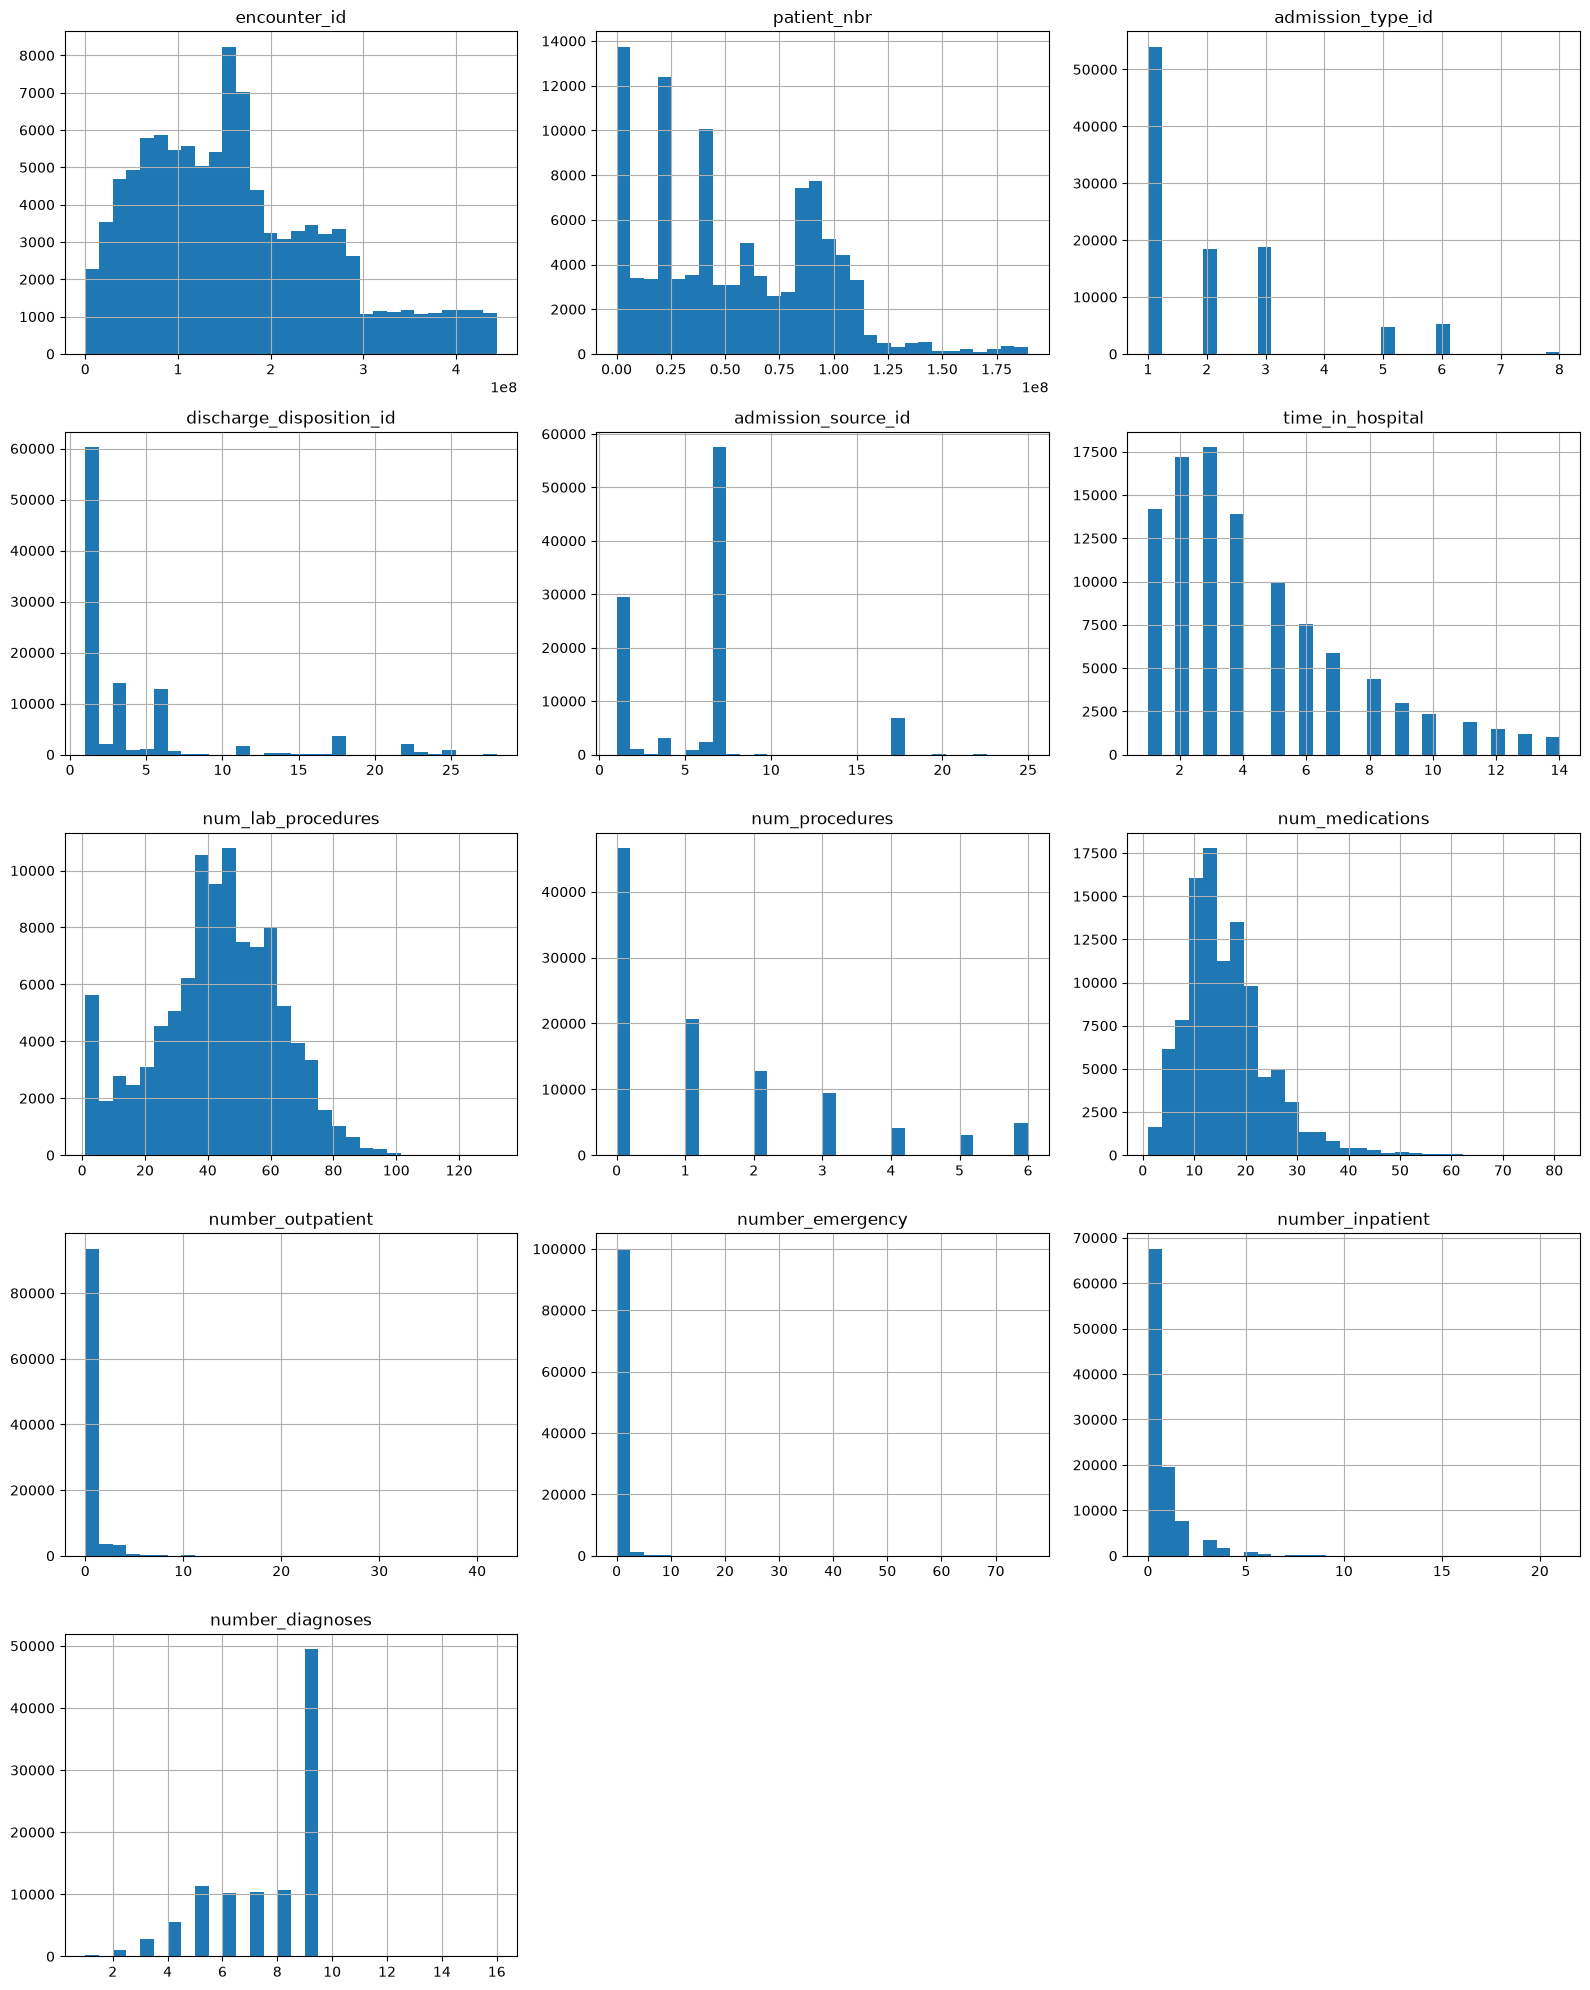

In [7]:
# Histograms for all numeric columns
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns ({len(numeric_cols)}):", numeric_cols)

df_raw[numeric_cols].hist(bins=30, figsize=(16, 20), layout=(5, 3))
plt.tight_layout()
plt.show()

In [8]:
# Inspect admission type, discharge disposition, admission source
for col in ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']:
    print(f"--- {col} ---")
    print(df_raw[col].value_counts().sort_index())
    print()

--- admission_type_id ---
admission_type_id
1    53990
2    18480
3    18869
4       10
5     4785
6     5291
7       21
8      320
Name: count, dtype: int64

--- discharge_disposition_id ---
discharge_disposition_id
1     60234
2      2128
3     13954
4       815
5      1184
6     12902
7       623
8       108
9        21
10        6
11     1642
12        3
13      399
14      372
15       63
16       11
17       14
18     3691
19        8
20        2
22     1993
23      412
24       48
25      989
27        5
28      139
Name: count, dtype: int64

--- admission_source_id ---
admission_source_id
1     29565
2      1104
3       187
4      3187
5       855
6      2264
7     57494
8        16
9       125
10        8
11        2
13        1
14        2
17     6781
20      161
22       12
25        2
Name: count, dtype: int64



### 2.3 Clean Data

**Columns dropped:**
- `weight` — 96.9% missing, too sparse to impute meaningfully
- `payer_code` — 39.6% missing, not clinically relevant to readmission

**Columns kept, missing values filled with "Missing" category:**
- `race` — 2.2% missing
- `medical_specialty` — 49.1% missing (missingness may itself carry signal)

**Columns kept as-is (missingness is informative, not noise):**
- `max_glu_serum`, `A1Cresult` — missing means "test not ordered," which is central to this project's research question

**Disguised missing values recoded (confirmed via IDs_mapping.csv):**
- `admission_type_id`: codes 5 (Not Available), 6 (NULL), 8 (Not Mapped) → recoded to -1 ("Missing")
- `discharge_disposition_id`: codes 18 (NULL), 25 (Not Mapped) → recoded to -1 ("Missing")
- `admission_source_id`: codes 9 (Not Available), 17 (NULL), 20 (Not Mapped) → recoded to -1 ("Missing")

**Rows removed:**
- Hospice/expired encounters — `discharge_disposition_id` in {11 (Expired), 13 (Hospice/home), 14 (Hospice/medical facility), 19 (Expired at home, Medicaid hospice), 20 (Expired in medical facility, Medicaid hospice)} — readmission is undefined for these patients
- Duplicate patient encounters — kept only the first encounter per `patient_nbr` (by ascending `encounter_id`) to preserve independence of observations and prevent train/test leakage
- `gender == 'Unknown/Invalid'` — negligible row count (<10), not a usable category for modeling

**Deferred to Feature Engineering step:**
- `diag_1/2/3` grouping into clinical ICD-9 categories
- Identifier columns (`encounter_id`, `patient_nbr`) will be excluded from model features (but kept in the dataframe for now, since `patient_nbr` is needed for the group-aware train/test split)

In [9]:
print("Rows before cleaning:", df_raw.shape[0])

df_clean = df_raw.copy()

# Drop high-missingness, low-relevance columns
df_clean = df_clean.drop(columns=['weight', 'payer_code'])

# Fill missing categoricals
df_clean['race'] = df_clean['race'].fillna('Missing')
df_clean['medical_specialty'] = df_clean['medical_specialty'].fillna('Missing')

# Recode disguised missing-value codes in ID columns to a unified "Missing" marker (-1)
df_clean['admission_type_id'] = df_clean['admission_type_id'].replace([5, 6, 8], -1)
df_clean['discharge_disposition_id'] = df_clean['discharge_disposition_id'].replace([18, 25], -1)
df_clean['admission_source_id'] = df_clean['admission_source_id'].replace([9, 17, 20], -1)

# Remove hospice/expired encounters (readmission undefined for these patients)
hospice_expired_codes = [11, 13, 14, 19, 20]
df_clean = df_clean[~df_clean['discharge_disposition_id'].isin(hospice_expired_codes)]

# Remove rows with invalid gender
df_clean = df_clean[df_clean['gender'] != 'Unknown/Invalid']

# Keep only the first encounter per patient (prevents train/test leakage)
df_clean = df_clean.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first')

print("Columns after cleaning:", df_clean.shape[1])
df_clean.head()

Rows before cleaning: 101766
Columns after cleaning: 48


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
8,12522,48330783,Caucasian,Female,[80-90),2,1,4,13,Missing,68,2,28,0,0,0,398,427,38,8,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),3,3,4,12,InternalMedicine,33,3,18,0,0,0,434,198,486,8,NaN,NaN,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,Missing,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
10,28236,89869032,AfricanAmerican,Female,[40-50),1,1,7,9,Missing,47,2,17,0,0,0,250.7,403,996,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,>30
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,Missing,31,6,16,0,0,0,414,411,250,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,>30


In [10]:
# Save cleaned data to processed
df_clean.to_csv("../data/processed/diabetic_data_clean.csv", index=False)
print(f"Saved {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")

Saved 69987 rows, 48 columns


In [11]:
# Track cleaned data with DVC
!"{sys.executable}" -m dvc add ../data/processed/diabetic_data_clean.csv
!git add ../data/processed/diabetic_data_clean.csv.dvc ../data/processed/.gitignore
!git commit -m "Track cleaned diabetic_data as v1 with DVC"

 ⠋ Checking graph
Adding...                                                                      
!
                                                                               
!
  0% Checking cache in '/Users/samisamim/ml-ops-final-group-3/.dvc/cache/files/
                                                                               
!
  0%|          |Adding ../data/processed/diabetic_dat0/1 [00:00<?,     ?file/s]
                                                                               
!
  0%|          |Checking out /Users/samisamim/ml-ops-0/1 [00:00<?,    ?files/s]
100% Adding...|███████████████████████████████████████|1/1 [00:00, 26.06file/s]

To track the changes with git, run:

	git add ../data/processed/diabetic_data_clean.csv.dvc

To enable auto staging, run:

	dvc config core.autostage true
[samimshs/automl-databricks ddea9b9] Track cleaned diabetic_data as v1 with DVC
 1 file changed, 2 insertions(+), 2 deletions(-)


## 3.0 Exploratory Data Analysis

### 3.1 Target Distribution

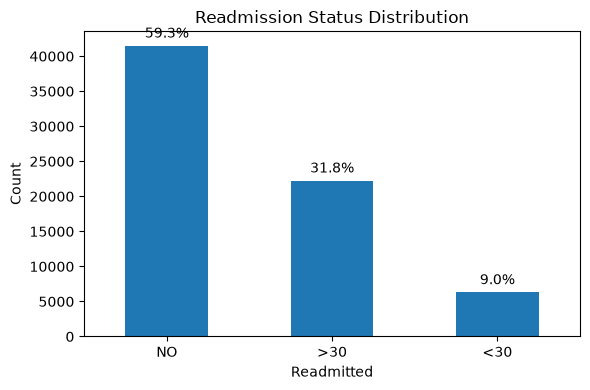

In [12]:
# Visualize
fig, ax = plt.subplots(figsize=(6, 4))
counts = df_clean['readmitted'].value_counts()
total = counts.sum()

bars = counts.plot(kind='bar', ax=ax)
ax.set_xlabel('Readmitted')
ax.set_ylabel('Count')
ax.set_title('Readmission Status Distribution')

# Add percentage labels above each bar
for i, count in enumerate(counts):
    pct = count / total * 100
    ax.text(i, count + total * 0.01, f'{pct:.1f}%', ha='center', va='bottom')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.2 Feature Review

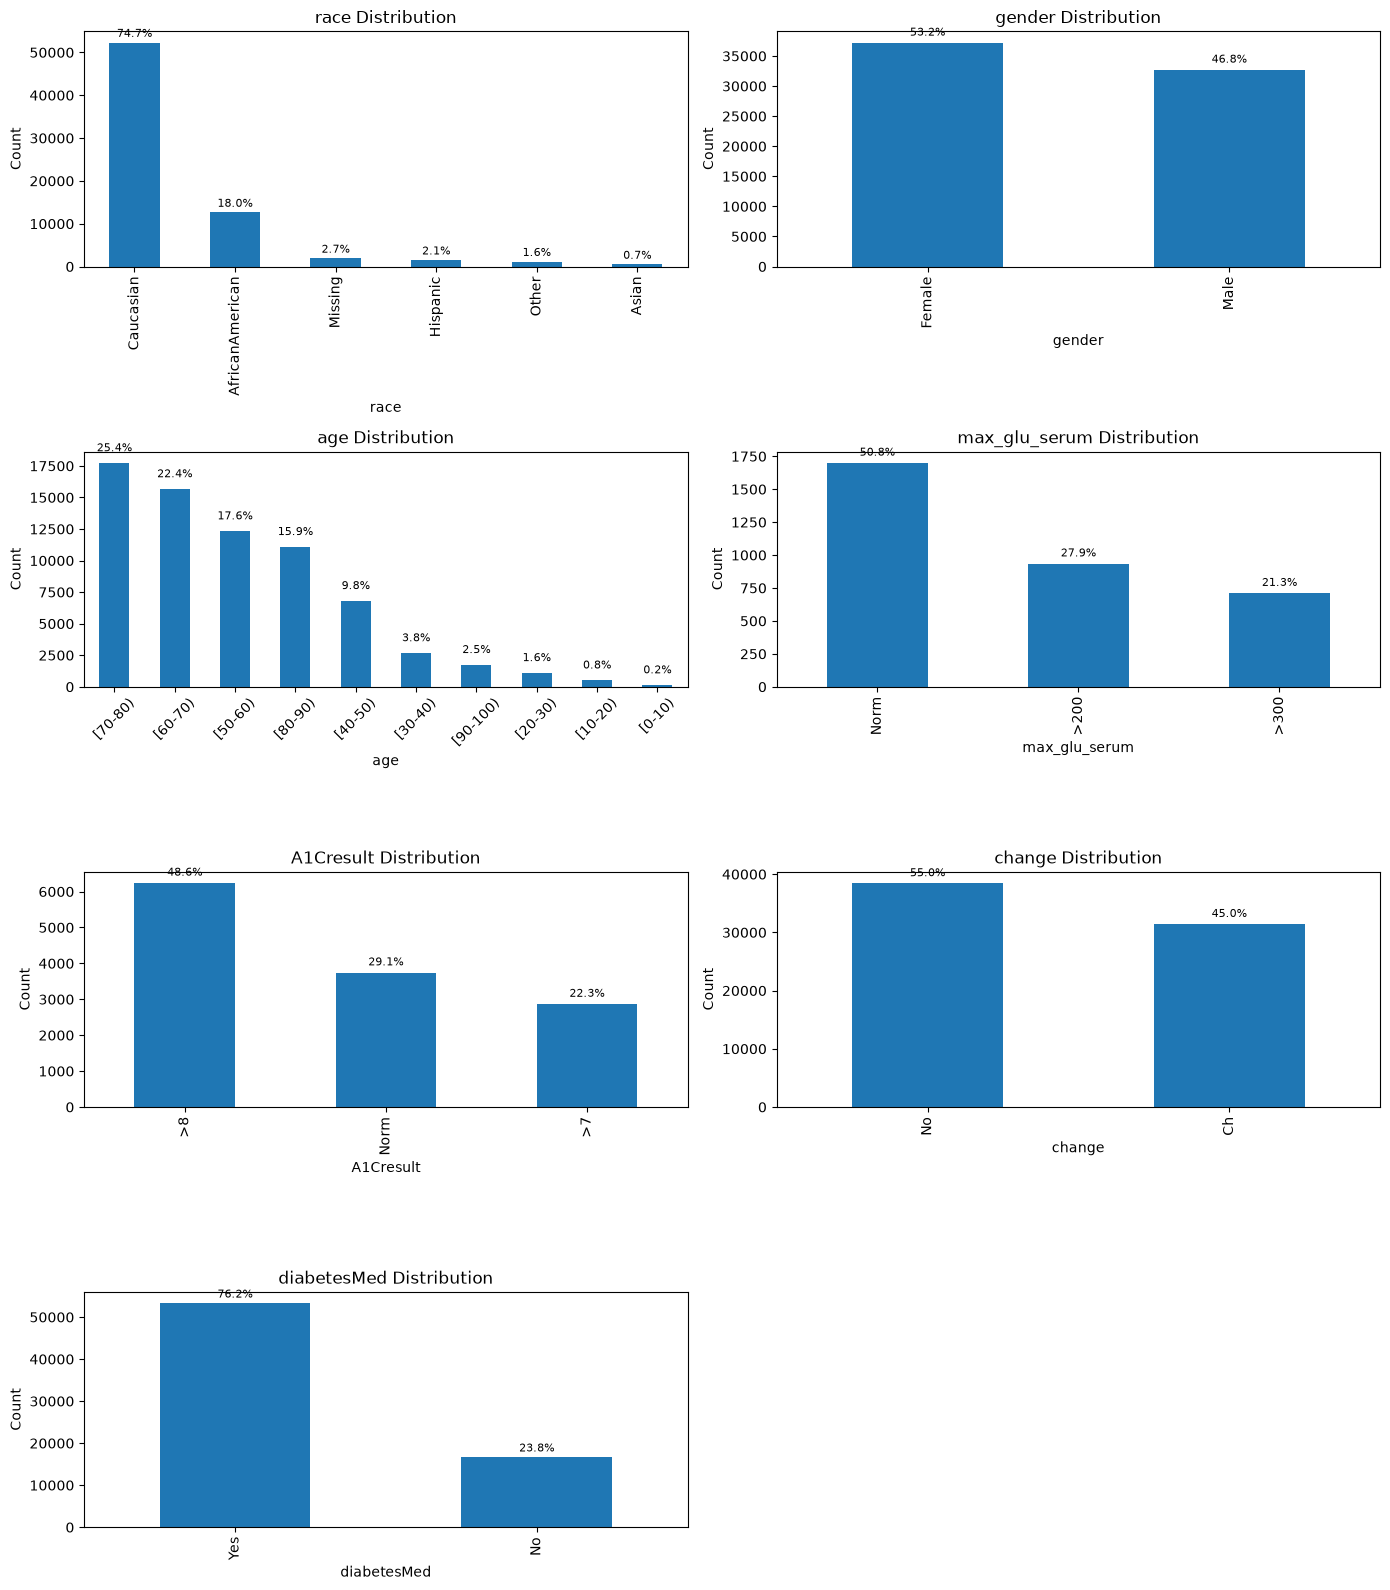

In [13]:
# Low-cardinality categoricals
low_card_cols = ['race', 'gender', 'age', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(low_card_cols):
    counts = df_clean[col].value_counts()
    total = counts.sum()

    counts.plot(kind='bar', ax=axes[i])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'{col} Distribution')

    for j, count in enumerate(counts):
        pct = count / total * 100
        axes[i].text(j, count + total * 0.01, f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

    if col == 'age':
        axes[i].tick_params(axis='x', rotation=45)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

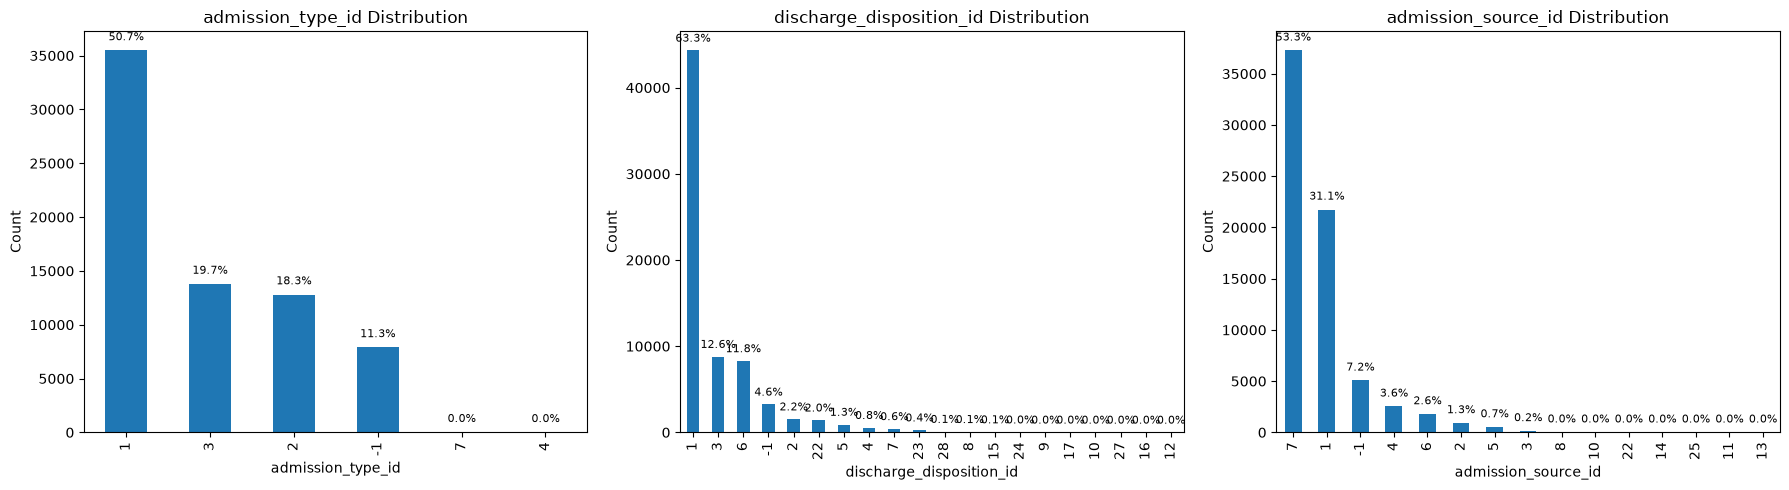

In [14]:
# Coded ID columns
id_cols = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(id_cols):
    counts = df_clean[col].value_counts()
    total = counts.sum()

    counts.plot(kind='bar', ax=axes[i])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'{col} Distribution')

    for j, count in enumerate(counts):
        pct = count / total * 100
        axes[i].text(j, count + total * 0.01, f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

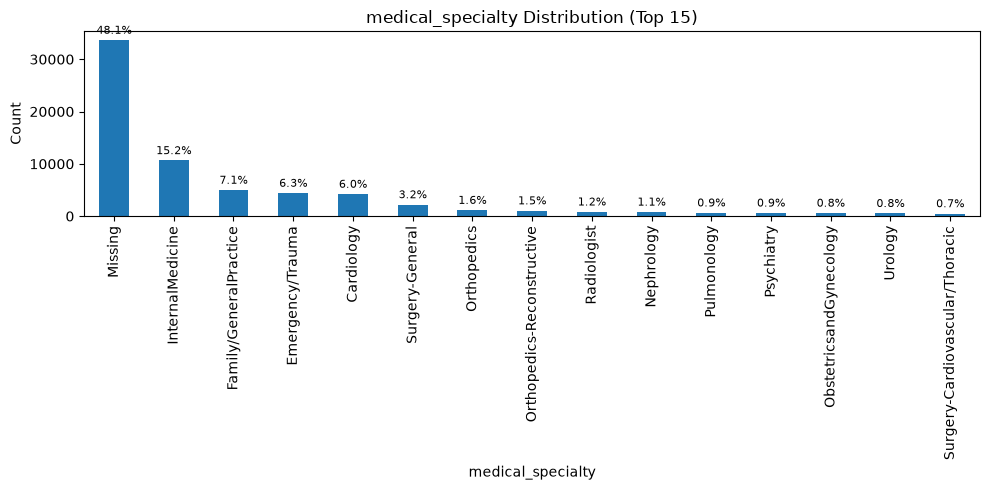

In [15]:
# medical_specialty — top 15 (high cardinality, ~84 raw categories)
top_specialties = df_clean['medical_specialty'].value_counts().head(15)
total = df_clean['medical_specialty'].value_counts().sum()

fig, ax = plt.subplots(figsize=(10, 5))
top_specialties.plot(kind='bar', ax=ax)
ax.set_xlabel('medical_specialty')
ax.set_ylabel('Count')
ax.set_title('medical_specialty Distribution (Top 15)')

for j, count in enumerate(top_specialties):
    pct = count / total * 100
    ax.text(j, count + total * 0.01, f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

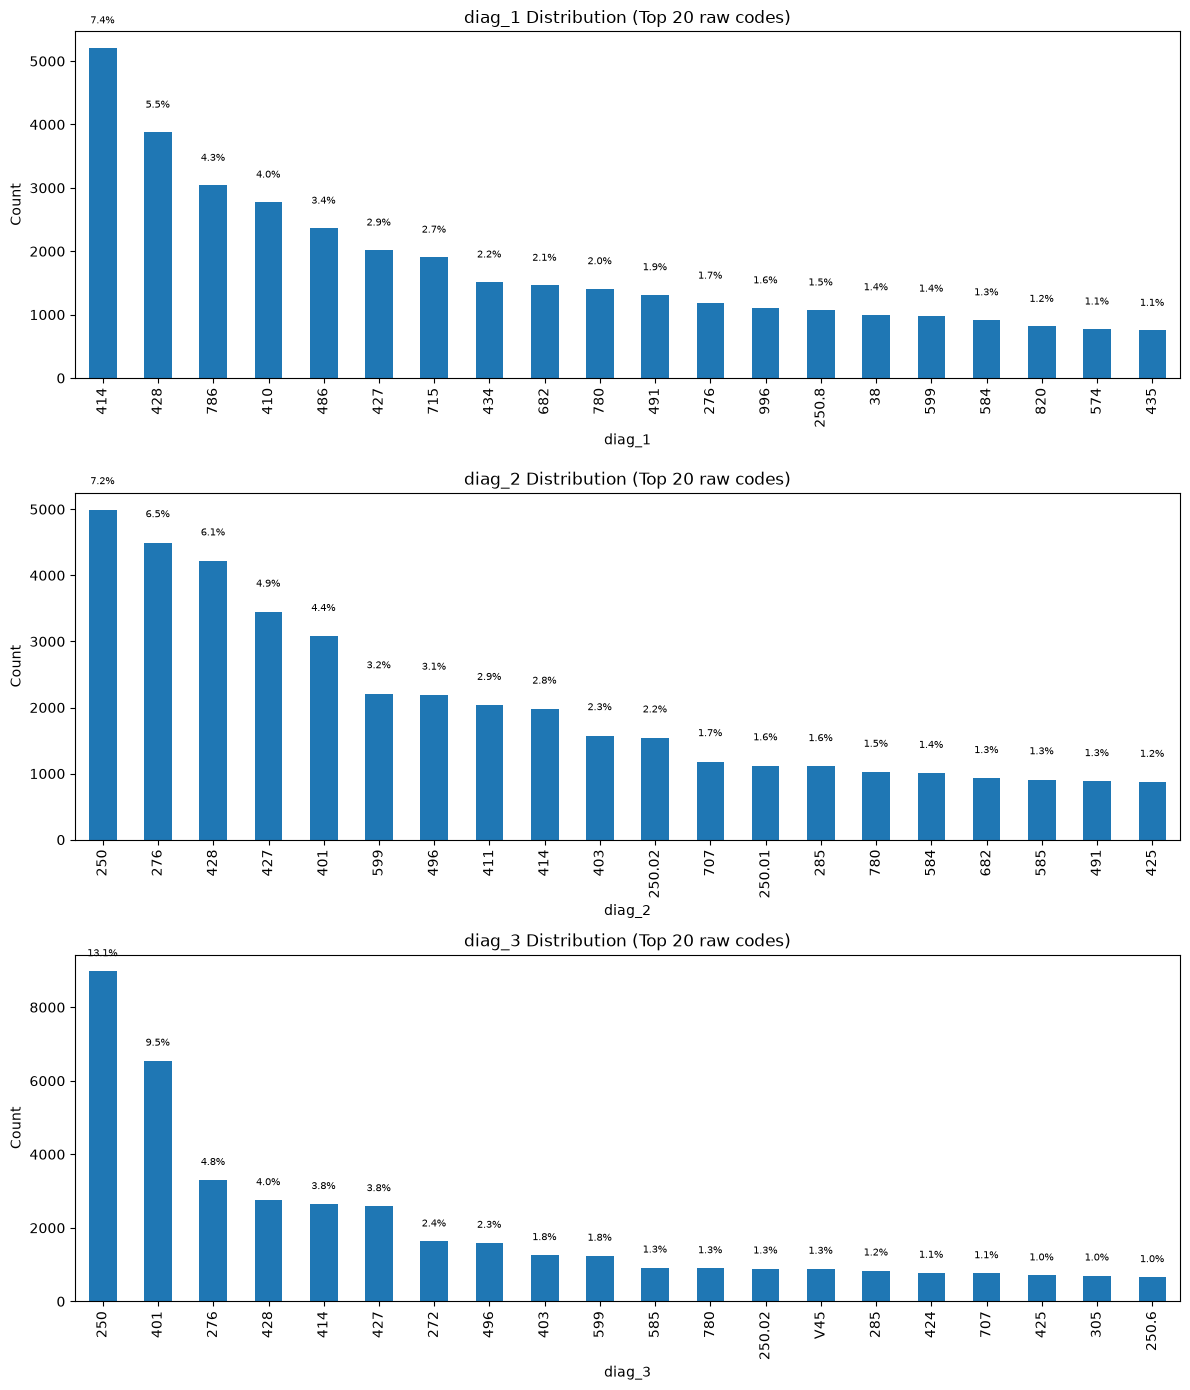

In [16]:
# Raw diag_1/2/3 distributions - top 20 codes each
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

for i, col in enumerate(['diag_1', 'diag_2', 'diag_3']):
    counts = df_clean[col].value_counts().head(20)
    total = df_clean[col].value_counts().sum()

    counts.plot(kind='bar', ax=axes[i])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'{col} Distribution (Top 20 raw codes)')

    for j, count in enumerate(counts):
        pct = count / total * 100
        axes[i].text(j, count + total * 0.005, f'{pct:.1f}%', ha='center', va='bottom', fontsize=7)

    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

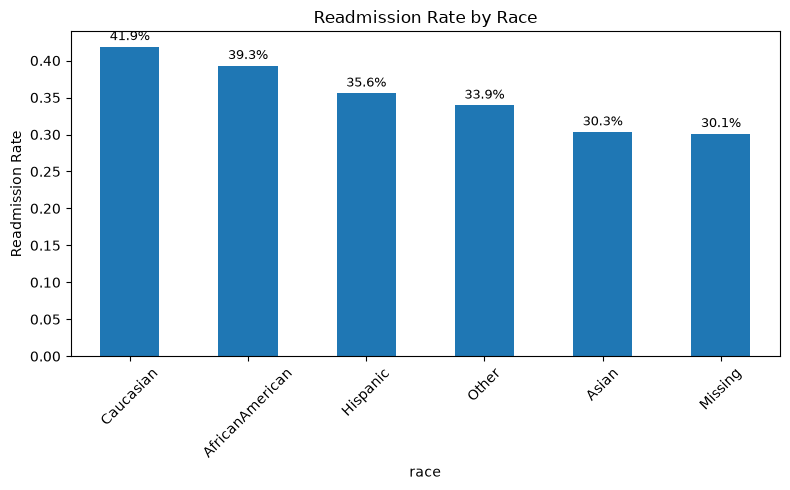

In [17]:
# Readmission rate by race
race_readmit = df_clean.groupby('race').apply(
    lambda x: (x['readmitted'] != 'NO').mean()
).sort_values(ascending=False)

race_counts = df_clean['race'].value_counts()

race_summary = pd.DataFrame({
    'count': race_counts,
    'readmission_rate': race_readmit
}).sort_values('readmission_rate', ascending=False)

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
race_summary['readmission_rate'].plot(kind='bar', ax=ax)
ax.set_xlabel('race')
ax.set_ylabel('Readmission Rate')
ax.set_title('Readmission Rate by Race')

for i, rate in enumerate(race_summary['readmission_rate']):
    ax.text(i, rate + 0.005, f'{rate:.1%}', ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# medical_specialty cumulative coverage - to inform bucketing threshold
specialty_pct = df_clean['medical_specialty'].value_counts(normalize=True) * 100
cumulative = specialty_pct.cumsum()

pd.DataFrame({'pct': specialty_pct.round(2), 'cumulative_pct': cumulative.round(2)}).head(20)

,pct,cumulative_pct
medical_specialty,,
Missing,48.08,48.08
InternalMedicine,15.20,63.29
Family/GeneralPractice,7.11,70.40
Emergency/Trauma,6.28,76.68
Cardiology,6.01,82.69
Surgery-General,3.15,85.84
Orthopedics,1.61,87.45
Orthopedics-Reconstructive,1.49,88.94
Radiologist,1.17,90.11


### 3.3 Correlations

In [19]:
# Continuous features + binary target correlation
continuous_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                    'num_medications', 'number_outpatient', 'number_emergency',
                    'number_inpatient', 'number_diagnoses']

# Temporary binary target for this correlation check (not yet finalized in df_clean)
corr_df = df_clean[continuous_cols].copy()
corr_df['readmitted_binary'] = (df_clean['readmitted'] != 'NO').astype(int)

corr_matrix = corr_df.corr()
corr_matrix

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted_binary
time_in_hospital,1.000000,0.332159,0.188410,0.467998,-0.015481,-0.009988,0.064036,0.233791,0.064741
num_lab_procedures,0.332159,1.000000,0.043854,0.259026,-0.007954,0.015498,0.079727,0.153915,0.054917
num_procedures,0.188410,0.043854,1.000000,0.400860,-0.018684,-0.035342,-0.023667,0.086471,-0.025803
num_medications,0.467998,0.259026,0.400860,1.000000,0.027047,0.003197,0.039414,0.259252,0.038803
number_outpatient,-0.015481,-0.007954,-0.018684,0.027047,1.000000,0.094806,0.068734,0.077164,0.065710
number_emergency,-0.009988,0.015498,-0.035342,0.003197,0.094806,1.000000,0.147747,0.049923,0.076904
number_inpatient,0.064036,0.079727,-0.023667,0.039414,0.068734,0.147747,1.000000,0.069880,0.146032
number_diagnoses,0.233791,0.153915,0.086471,0.259252,0.077164,0.049923,0.069880,1.000000,0.110881
readmitted_binary,0.064741,0.054917,-0.025803,0.038803,0.065710,0.076904,0.146032,0.110881,1.000000


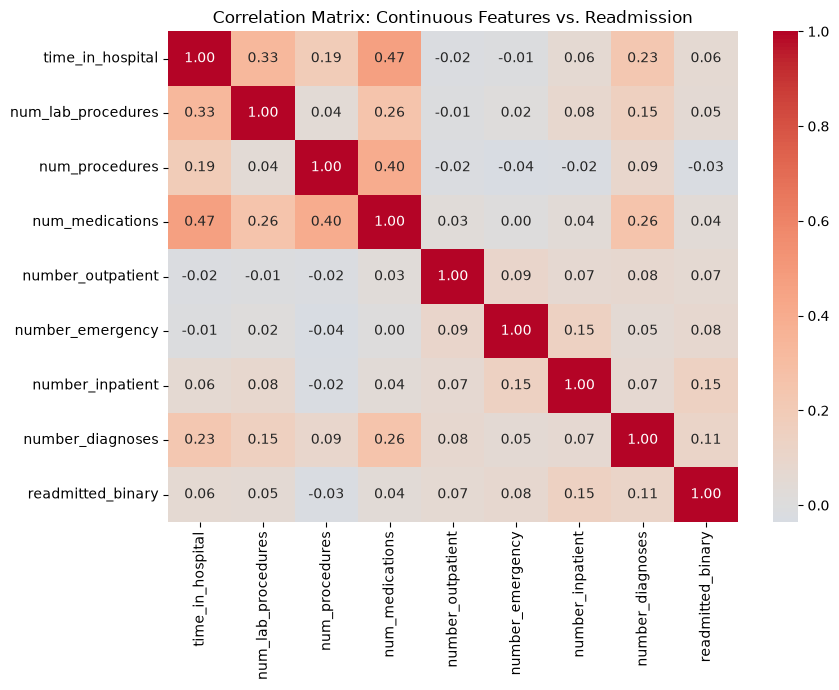

In [20]:
# Heatmap
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix: Continuous Features vs. Readmission')
plt.tight_layout()
plt.show()

## 4.0 Feature Engineering

**Target variable:**
- `readmitted_binary` = 1 if `readmitted != 'NO'` (any readmission), else 0 — chosen over the source paper's `<30`-only definition after reviewing the 3-class distribution (NO 59.3% / >30 31.8% / <30 9.0%); gives a more balanced ~41/59 split

**Diagnosis grouping:**
- `diag_1` (primary diagnosis) grouped into 9 clinical categories per Strack et al. (2014), Table 2: Circulatory, Respiratory, Digestive, Diabetes, Injury, Musculoskeletal, Genitourinary, Neoplasms, Other (includes V/E codes)
- `diag_2`/`diag_3` left ungrouped for the baseline model, matching the paper; possible enhancement later

**medical_specialty bucketing:**
- Categories with ≥1% of rows kept as-is (10 categories: Missing, InternalMedicine, Family/GeneralPractice, Emergency/Trauma, Cardiology, Surgery-General, Orthopedics, Orthopedics-Reconstructive, Radiologist, Nephrology), covering 91.25% of the data
- All remaining categories (~74 distinct specialties, ~8.75% of rows) bucketed into "Other"

**Race:**
- Binary `race_white` feature: Caucasian vs. Other — chosen despite AfricanAmerican (39.3% readmission rate) being statistically closer to Caucasian (41.9%) than to other categories (30-36%); kept as originally planned

**Identifier columns:**
- `encounter_id`, `patient_nbr` excluded from model features, but retained in the dataframe (needed for Feast entity keys and any future patient-level grouping)

**Age encoding:**
- `age` converted from its 10-year string bins (e.g., `[50-60)`) to an ordinal integer (0-9), since the bins have a natural order — preserves that ordering for the model rather than treating age groups as unrelated categories

### 4.1 Build Features

In [21]:
df_features = df_clean.copy()

# Binary target: any readmission (<30 or >30) vs no readmission
df_features['readmitted_binary'] = (df_features['readmitted'] != 'NO').astype(int)

# Diagnosis grouping: diag_1 (primary diagnosis) into 9 clinical categories (Strack et al. 2014, Table 2)
def categorize_diagnosis(code):
    if pd.isna(code):
        return 'Missing'
    code = str(code)
    if code.startswith('V') or code.startswith('E'):
        return 'Other'
    try:
        code_num = float(code)
    except ValueError:
        return 'Other'

    if 390 <= code_num <= 459 or code_num == 785:
        return 'Circulatory'
    elif 460 <= code_num <= 519 or code_num == 786:
        return 'Respiratory'
    elif 520 <= code_num <= 579 or code_num == 787:
        return 'Digestive'
    elif 250 <= code_num < 251:
        return 'Diabetes'
    elif 800 <= code_num <= 999:
        return 'Injury'
    elif 710 <= code_num <= 739:
        return 'Musculoskeletal'
    elif 580 <= code_num <= 629 or code_num == 788:
        return 'Genitourinary'
    elif 140 <= code_num <= 239:
        return 'Neoplasms'
    else:
        return 'Other'

df_features['diag_1_category'] = df_features['diag_1'].apply(categorize_diagnosis)

# medical_specialty bucketing: keep categories >= 1% of rows, bucket rest into "Other"
specialty_counts = df_clean['medical_specialty'].value_counts(normalize=True) * 100
keep_specialties = specialty_counts[specialty_counts >= 1.0].index.tolist()

df_features['medical_specialty_grouped'] = df_clean['medical_specialty'].apply(
    lambda x: x if x in keep_specialties else 'Other'
)

# Binary race feature: Caucasian vs. Other
df_features['race_white'] = (df_features['race'] == 'Caucasian').astype(int)

# Age encoding: convert ordinal age bins to integer (0-9), preserving natural order
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
age_map = {age: i for i, age in enumerate(age_order)}

df_features['age_ordinal'] = df_features['age'].map(age_map)

# Identifier columns (encounter_id, patient_nbr) intentionally retained in df_features,
# not dropped here -- excluded from the model's feature set at train time, but needed
# for Feast entity keys and patient-level grouping

print("Target:")
print(df_features['readmitted_binary'].value_counts(normalize=True).round(3))
print()
print("diag_1_category:")
print(df_features['diag_1_category'].value_counts())
print()
print("medical_specialty_grouped:")
print(df_features['medical_specialty_grouped'].value_counts())
print()
print("race_white:")
print(df_features['race_white'].value_counts(normalize=True).round(3))
print()
print("age_ordinal:")
print(df_features['age_ordinal'].value_counts().sort_index())

Target:
readmitted_binary
0    0.593
1    0.407
Name: proportion, dtype: float64

diag_1_category:
diag_1_category
Circulatory        21389
Other              12124
Respiratory         9491
Digestive           6488
Diabetes            5748
Injury              4694
Musculoskeletal     4064
Genitourinary       3441
Neoplasms           2538
Missing               10
Name: count, dtype: int64

medical_specialty_grouped:
medical_specialty_grouped
Missing                       33652
InternalMedicine              10641
Other                          6124
Family/GeneralPractice         4978
Emergency/Trauma               4393
Cardiology                     4207
Surgery-General                2205
Orthopedics                    1128
Orthopedics-Reconstructive     1041
Radiologist                     821
Nephrology                      797
Name: count, dtype: int64

race_white:
race_white
1    0.747
0    0.253
Name: proportion, dtype: float64

age_ordinal:
age_ordinal
0      153
1      534
2     

In [22]:
print("Shape:", df_features.shape)
print()
print("Columns:")
df_features.columns.tolist()

Shape: (69987, 53)

Columns:


['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted',
 'readmitted_binary',
 'diag_1_category',
 'medical_specialty_grouped',
 'race_white',
 'age_ordinal']

### 4.2 Save Feature Set

In [23]:
df_features.to_csv("../data/processed/diabetic_data_features.csv", index=False)
print(f"Saved {df_features.shape[0]} rows, {df_features.shape[1]} columns")

Saved 69987 rows, 53 columns


In [24]:
!"{sys.executable}" -m dvc add ../data/processed/diabetic_data_features.csv
!git add ../data/processed/diabetic_data_features.csv.dvc
!git commit -m "Track engineered features (v2) with DVC"

 ⠋ Checking graph
Adding...                                                                      
!
                                                                               
!
  0% Checking cache in '/Users/samisamim/ml-ops-final-group-3/.dvc/cache/files/
                                                                               
!
  0%|          |Adding ../data/processed/diabetic_dat0/1 [00:00<?,     ?file/s]
                                                                               
!
  0%|          |Checking out /Users/samisamim/ml-ops-0/1 [00:00<?,    ?files/s]
100% Adding...|███████████████████████████████████████|1/1 [00:00, 24.20file/s]

To track the changes with git, run:

	git add ../data/processed/diabetic_data_features.csv.dvc

To enable auto staging, run:

	dvc config core.autostage true
[samimshs/automl-databricks ba8c600] Track engineered features (v2) with DVC
 1 file changed, 2 insertions(+), 2 deletions(-)


### 4.3 Feast Registry

In [25]:
feature_definitions = '''
from feast import Entity, FeatureView, Field, FileSource
from feast.types import Int64, String
from datetime import timedelta

encounter = Entity(name="encounter", join_keys=["encounter_id"])

diabetes_source = FileSource(
    path="data/diabetes_features.parquet",
    timestamp_field="event_timestamp",
)

diabetes_features_v1 = FeatureView(
    name="diabetes_features_v1",
    entities=[encounter],
    ttl=timedelta(days=3650),
    schema=[
        Field(name="time_in_hospital", dtype=Int64),
        Field(name="num_lab_procedures", dtype=Int64),
        Field(name="num_procedures", dtype=Int64),
        Field(name="num_medications", dtype=Int64),
        Field(name="number_outpatient", dtype=Int64),
        Field(name="number_emergency", dtype=Int64),
        Field(name="number_inpatient", dtype=Int64),
        Field(name="number_diagnoses", dtype=Int64),
        Field(name="admission_type_id", dtype=Int64),
        Field(name="discharge_disposition_id", dtype=Int64),
        Field(name="admission_source_id", dtype=Int64),
        Field(name="diag_1_category", dtype=String),
        Field(name="medical_specialty_grouped", dtype=String),
        Field(name="race_white", dtype=Int64),
        Field(name="gender", dtype=String),
        Field(name="age_ordinal", dtype=Int64),
    ],
    source=diabetes_source,
)
'''

with open("../feast_repo/feature_repo/feature_definitions.py", "w") as f:
    f.write(feature_definitions)

print("Wrote feature_definitions.py")

Wrote feature_definitions.py


In [27]:
df_features['event_timestamp'] = pd.Timestamp.now()

df_features.to_parquet(
    "../feast_repo/feature_repo/data/diabetes_features.parquet",
    index=False,
    engine="pyarrow"
)
print(f"Saved {df_features.shape[0]} rows, {df_features.shape[1]} columns")

Saved 69987 rows, 54 columns


In [28]:
result = subprocess.run(
    ["feast", "apply"],
    cwd="../feast_repo/feature_repo",
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print("ERROR running feast apply:")
    print(result.stderr)

No project found in the repository. Using project name feast_repo defined in feature_store.yaml
Applying changes for project feast_repo
No changes to registry
Updated sqlite table feast_repo_diabetes_features_v1
	path: c:\Users\nelse\Documents\U Chicago\Machine Learning Operations\Final Project\ml-ops-final-group-3\feast_repo\feature_repo\data\online_store.db -> /Users/samisamim/ml-ops-final-group-3/feast_repo/feature_repo/data/online_store.db




### 4.4 Feast Retrieval

In [29]:
store = FeatureStore(repo_path="../feast_repo/feature_repo")

df_entity = df_features[["encounter_id", "event_timestamp", "readmitted_binary"]]

df_retrieved = store.get_historical_features(
    entity_df=df_entity,
    features=[
        "diabetes_features_v1:time_in_hospital",
        "diabetes_features_v1:num_lab_procedures",
        "diabetes_features_v1:num_procedures",
        "diabetes_features_v1:num_medications",
        "diabetes_features_v1:number_outpatient",
        "diabetes_features_v1:number_emergency",
        "diabetes_features_v1:number_inpatient",
        "diabetes_features_v1:number_diagnoses",
        "diabetes_features_v1:admission_type_id",
        "diabetes_features_v1:discharge_disposition_id",
        "diabetes_features_v1:admission_source_id",
        "diabetes_features_v1:diag_1_category",
        "diabetes_features_v1:medical_specialty_grouped",
        "diabetes_features_v1:race_white",
        "diabetes_features_v1:gender",
        "diabetes_features_v1:age_ordinal",
    ],
).to_df()

print("Retrieved shape:", df_retrieved.shape)
df_retrieved.head()

Retrieved shape: (69987, 19)


,encounter_id,event_timestamp,readmitted_binary,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,admission_type_id,discharge_disposition_id,admission_source_id,diag_1_category,medical_specialty_grouped,race_white,gender,age_ordinal
0,2278392,2026-08-14 17:56:49.913582+00:00,0,1,41,0,1,0,0,0,1,-1,-1,1,Diabetes,Other,1,Female,0
1,177225696,2026-08-14 17:56:49.913582+00:00,1,2,10,0,16,1,0,0,4,1,1,7,Circulatory,Missing,1,Female,5
2,177234156,2026-08-14 17:56:49.913582+00:00,1,4,34,3,11,0,0,0,9,3,2,1,Other,Other,1,Male,5
3,177236256,2026-08-14 17:56:49.913582+00:00,0,1,26,2,18,0,0,0,6,3,6,1,Other,Orthopedics-Reconstructive,1,Female,5
4,177236358,2026-08-14 17:56:49.913582+00:00,0,6,40,2,11,0,0,0,9,1,1,7,Injury,Missing,1,Female,2


## 5.0 Train/Test Split

In [30]:
# Config
RANDOM_STATE = 42
TEST_SIZE = 0.2

In [31]:
feature_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                'num_medications', 'number_outpatient', 'number_emergency',
                'number_inpatient', 'number_diagnoses', 'admission_type_id',
                'discharge_disposition_id', 'admission_source_id',
                'diag_1_category', 'medical_specialty_grouped', 'race_white',
                'gender', 'age_ordinal']

X = df_features[feature_cols]
y = df_features['readmitted_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (55989, 16)
Test shape: (13998, 16)


In [32]:
# One hot encoding
categorical_cols = ['diag_1_category', 'medical_specialty_grouped', 'gender']

X_train = pd.get_dummies(X_train, columns=categorical_cols, dtype=int)
X_test = pd.get_dummies(X_test, columns=categorical_cols, dtype=int)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
X_train.head()

X_train shape: (55989, 36)
X_test shape: (13998, 36)


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,admission_type_id,discharge_disposition_id,admission_source_id,race_white,age_ordinal,diag_1_category_Circulatory,diag_1_category_Diabetes,diag_1_category_Digestive,diag_1_category_Genitourinary,diag_1_category_Injury,diag_1_category_Missing,diag_1_category_Musculoskeletal,diag_1_category_Neoplasms,diag_1_category_Other,diag_1_category_Respiratory,medical_specialty_grouped_Cardiology,medical_specialty_grouped_Emergency/Trauma,medical_specialty_grouped_Family/GeneralPractice,medical_specialty_grouped_InternalMedicine,medical_specialty_grouped_Missing,medical_specialty_grouped_Nephrology,medical_specialty_grouped_Orthopedics,medical_specialty_grouped_Orthopedics-Reconstructive,medical_specialty_grouped_Other,medical_specialty_grouped_Radiologist,medical_specialty_grouped_Surgery-General,gender_Female,gender_Male
100697,9,42,0,23,0,0,0,9,2,1,1,1,7,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0
42903,4,32,1,15,0,0,0,9,2,1,1,1,7,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
30874,5,29,0,22,1,0,2,9,3,1,1,0,6,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1
71299,5,40,0,22,0,0,0,5,3,1,1,1,9,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0
88197,3,33,0,13,1,0,0,5,3,1,1,1,7,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0


## 6.0 Baseline Model

In [33]:
model_baseline = XGBClassifier(random_state=RANDOM_STATE)
model_baseline.fit(X_train, y_train)

y_pred = model_baseline.predict(X_test)
y_pred_proba = model_baseline.predict_proba(X_test)[:, 1]

print("F1 score:", round(f1_score(y_test, y_pred), 3))
print("AUC-ROC:", round(roc_auc_score(y_test, y_pred_proba), 3))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

F1 score: 0.436
AUC-ROC: 0.648

Confusion Matrix:
[[6725 1571]
 [3676 2026]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.81      0.72      8296
           1       0.56      0.36      0.44      5702

    accuracy                           0.63     13998
   macro avg       0.60      0.58      0.58     13998
weighted avg       0.61      0.63      0.60     13998



In [34]:
# Feature Importance
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_baseline.feature_importances_
}).sort_values('importance', ascending=False)

importance_df.head(15)

,feature,importance
6,number_inpatient,0.179309
5,number_emergency,0.046599
28,medical_specialty_grouped_Nephrology,0.041609
7,number_diagnoses,0.039361
14,diag_1_category_Diabetes,0.035638
24,medical_specialty_grouped_Emergency/Trauma,0.035445
30,medical_specialty_grouped_Orthopedics-Reconstr...,0.033403
10,admission_source_id,0.031247
12,age_ordinal,0.028240
8,admission_type_id,0.028113


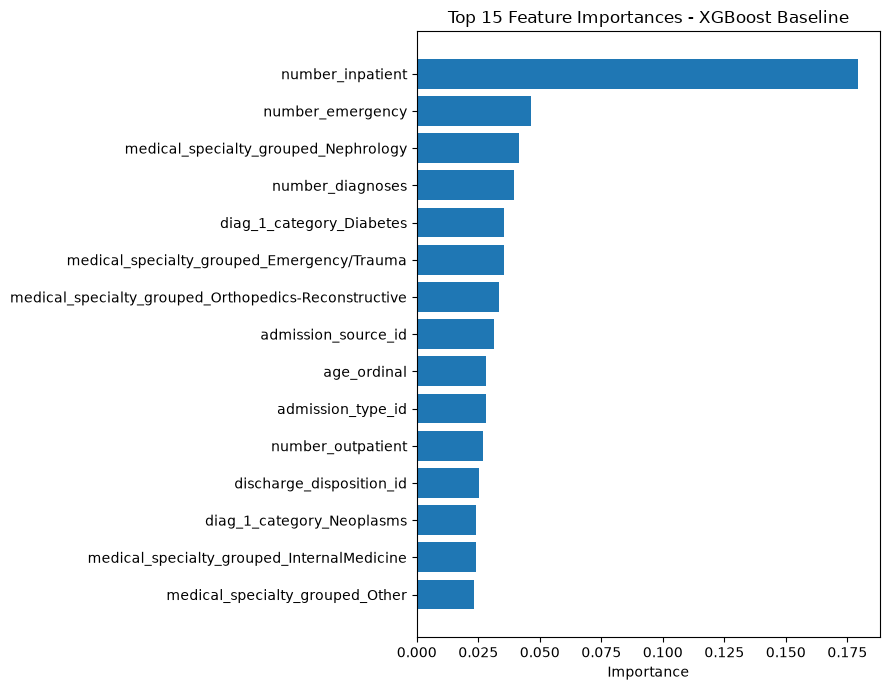

In [35]:
fig, ax = plt.subplots(figsize=(9, 7))
top_features = importance_df.head(15)
ax.barh(top_features['feature'], top_features['importance'])
ax.set_xlabel('Importance')
ax.set_title('Top 15 Feature Importances - XGBoost Baseline')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [36]:
import pickle
import json
from pathlib import Path

Path("../models").mkdir(exist_ok=True)
Path("../metrics").mkdir(exist_ok=True)

# Save model
with open("../models/model_baseline.pkl", "wb") as f:
    pickle.dump(model_baseline, f)
print("Saved model_baseline.pkl")

# Save metrics
metrics = {
    "model": "XGBoost baseline (default params)",
    "f1_score": round(f1_score(y_test, y_pred), 3),
    "auc_roc": round(roc_auc_score(y_test, y_pred_proba), 3),
    "precision": round(classification_report(y_test, y_pred, output_dict=True)["1"]["precision"], 3),
    "recall": round(classification_report(y_test, y_pred, output_dict=True)["1"]["recall"], 3),
    "accuracy": round(classification_report(y_test, y_pred, output_dict=True)["accuracy"], 3),
    "train_shape": list(X_train.shape),
    "test_shape": list(X_test.shape),
}

with open("../metrics/metrics_baseline.json", "w") as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics, indent=2))

Saved model_baseline.pkl
{
  "model": "XGBoost baseline (default params)",
  "f1_score": 0.436,
  "auc_roc": 0.648,
  "precision": 0.563,
  "recall": 0.355,
  "accuracy": 0.625,
  "train_shape": [
    55989,
    36
  ],
  "test_shape": [
    13998,
    36
  ]
}
